## Lab4
### Topic: Advanced Net

### Завдання №1: Генерація тексту

Спершу доречно буде порівняти архітектури: RNN (LSTM/GRU) vs Transformers -- яку з них краще обрати.

Рекурентні мережі (LSTM/GRU):

_**Переваги:**_
- Простіша архітектура, легше зрозуміти та реалізувати
- Менші вимоги до обчислювальних ресурсів
- Добре працюють з невеликими датасетами (< 10 МБ тексту)
- Послідовна обробка для текстових послідовностей

_**Недоліки:**_
- Проблема зникаючого градієнта (vanishing gradient problem) на довгих послідовностях, оскільки RNN "забуває" що було на початку речення.
- Неможливо паралелізувати навчання (в RNN кожен крок залежить від попереднього, а-ля конвеєр)
- Обмежена "пам'ять" контексту (~100-500 символів). Я фіксуватиму розмір вектору hidden state у 256 чисел. Сюди треба ж запхати достобіса інформації (щось стиснеться, щось затреться) -- загалом погано, але все ж це оптимально для обраного мною датасету. Оскільки якщо число це більше -- модель потужніша, але повільніша + шанс перенавчання, а менше -- швидша, але "тупіша".

Трансформери (GPT, BERT):

_**Переваги:**_
- Механізм уваги (attention) дозволяє враховувати весь контекст
- Легко паралелізуються на GPU (це а-ля кухня в ресторані, де кожен кухар готує щось своє)
- Кращі результати на великих датасетах (>100 МБ) або на fine-tuning (попередньо навчених) моделях, таких як GPT-2, mGPT.
- Можуть генерувати більш зв'язний і узгоджений між собою текст

_**Недоліки:**_
- Потребують значно більше даних для навчання (гігабайти)
- Великі обчислювальні витрати
- Складніша реалізація
- Квадратична складність, залежить від довжини послідовності $\mathcal{O}(L)$

Отже, оскільки я беру датасет https://www.kaggle.com/datasets/mykras/ukrainian-texts (~2 МБ українських текстів) відносно невеликий, то оптимальним вибором є LSTM, та й GPU в мене дуже слабке, то ж краще так, чим ніяк))

1. LSTM навчатиму на CPU за "адекватний (пару годинок)" час.
2. LSTM краще демонструє принципи послідовної генерації (буду виводити)
3. Також, оскільки працюватиму з українською мовою, яка багата на морфологічні форми, використаю character-level підхід, що дозволяє генерувати нові словоформи


#### Теоретичні основи LSTM

П### Архітектура LSTM (Long Short-Term Memory)

LSTM вирішує проблему зникаючого градієнта через систему "воріт" (gates):

**1. Forget Gate (ворота забування):**
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

Визначає, яку інформацію з попереднього стану комірки забути.

**2. Input Gate (ворота входу):**
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tan(W_C \cdot [h_{t-1}, x_t] + b_C)$$

Визначає, яку нову інформацію зберегти.

**3. Cell State Update (оновлення стану комірки):**
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**4. Output Gate (ворота виходу):**
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tan(C_t)$$

де $\sigma$ — сигмоїда, $\odot$ — поелементне множення.

### Character-level Language Model

Модель навчається передбачати наступний символ на основі попередніх:

$$P(c_t | c_1, c_2, ..., c_{t-1})$$

При генерації використовується **temperature sampling**:

$$P(c_i) = \frac{\exp(z_i / T)}{\sum\limits_j \exp(z_j / T)}$$

де $T$ — температура (T<1 — більш детерміновано, T>1 — більш випадково).

## Імплементація

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import re
from collections import Counter
import matplotlib.pyplot as plt

### 1. Завантаження та попередня обробка тексту

In [16]:
def load_texts(file_paths):
    """Об'єднуємо всі тексти з файлів"""
    all_text = ""
    for path in file_paths:
        try:
            for encoding in ['utf-8', 'cp1251']:
                try:
                    with open(path, 'r', encoding=encoding) as f:
                        text = f.read()
                        all_text += text + "\n\n"
                        print(f"Завантажено: {os.path.basename(path)} ({len(text):,} символів, кодування: {encoding})")
                        break
                except UnicodeDecodeError:
                    continue
        except Exception as e:
            print(f"Помилка завантаження {path}: {e}")
    return all_text

def preprocess_text(text):
    """Очищення та нормалізація тексту"""

    text = text.replace('\ufeff', '').replace('\r', '') #  Byte Order Mark and normalize line endings

    # Normalize whitespaces
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)

    # Allow only this сhars, to help model focus on language patters - filter out rare symbols
    allowed_chars = set('абвгґдеєжзиіїйклмнопрстуфхцчшщьюяАБВГҐДЕЄЖЗИІЇЙКЛМНОПРСТУФХЦЧШЩЬЮЯ '
                    'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'
                    '0123456789.,!?;:\'\"\n—–-()[]«»')
    text = ''.join(c if c in allowed_chars else ' ' for c in text)

    # Normalization again after filtering
    text = re.sub(r' +', ' ', text)

    return text.strip()

# Шляхи до файлів
file_paths = [
    r"var_data/Franko_-Zibrannya-tvoriv.txt",
    r"var_data/Lisova_pisnya.txt",
    r"var_data/Lys_mykyta.txt"
]

# Завантажуємо власне тексти
raw_text = load_texts(file_paths)
text = preprocess_text(raw_text)

print(f"\nЗагальний розмір тексту: {len(text):,} символів")
print(f"Приклад тексту:\n{text[2000:2500]}")

Завантажено: Franko_-Zibrannya-tvoriv.txt (1,055,190 символів, кодування: utf-8)
Завантажено: Lisova_pisnya.txt (92,883 символів, кодування: utf-8)
Завантажено: Lys_mykyta.txt (86,406 символів, кодування: utf-8)

Загальний розмір тексту: 1,218,698 символів
Приклад тексту:
трібні для його характеристики. Побажаємо йому й нашій літературі, щоб ті рамки ще довго і довго треба Суло розширювати.
 7
 [ДОДАТОК ДО СТАТТІ М. КОМАРА «ЄВГЕН БОРИСІВ . ПОСМЕРТНА ЗГАДКА»]
 Додаю ще кілька слів і від себе. Є. Борисова я пізнав у 1878 р., коли він — не тямно, з якою метою,— пробував кілька тижнів у Львові. Тоді я разом з д. Павликом редагував «Громадський друг» , якого кожна книжка була конфіскована і який наслідком того в другій половині року виходив у формі альманахів «Дзвін» 


### 2. Створення словника символів та кодування

In [17]:
class CharVocabulary:
    """Клас для роботи зі словником символів"""

    def __init__(self, text, min_freq=1):
        # Підрахунок частоти символів
        char_counts = Counter(text)

        # Фільтрація за мінімальною частотою
        chars = [c for c, count in char_counts.items() if count >= min_freq]
        chars = sorted(chars)

        # Додаємо спеціальні токени
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'

        # Створення словників
        self.char_to_idx = {self.pad_token: 0, self.unk_token: 1}
        for i, char in enumerate(chars, start=2):
            self.char_to_idx[char] = i

        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}
        self.vocab_size = len(self.char_to_idx)

    def encode(self, text):
        """Перетворення тексту в послідовність індексів"""
        return [self.char_to_idx.get(c, self.char_to_idx[self.unk_token]) for c in text]

    def decode(self, indices):
        """Перетворення послідовності індексів в текст"""
        return ''.join(self.idx_to_char.get(idx, self.unk_token) for idx in indices)

# Створення словника
vocab = CharVocabulary(text)
print(f"Розмір словника: {vocab.vocab_size} унікальних символів")
print(f"\nПриклади символів: {list(vocab.char_to_idx.keys())[2:20]}")

# Тест кодування/декодування
test_text = "Привіт, світе!"
encoded = vocab.encode(test_text)
decoded = vocab.decode(encoded)
print(f"\nТест: '{test_text}' -> {encoded} -> '{decoded}'")

Розмір словника: 149 унікальних символів

Приклади символів: ['\n', ' ', '!', '"', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7']

Тест: 'Привіт, світе!' -> [99, 129, 121, 115, 143, 131, 9, 3, 130, 115, 143, 131, 118, 4] -> 'Привіт, світе!'


### 3. Підготовка датасету

In [18]:
class TextDataset(Dataset):
    """Dataset для character-level language modeling"""

    def __init__(self, text, vocab, seq_length=100):
        self.vocab = vocab
        self.seq_length = seq_length

        # Кодуємо весь текст
        self.data = torch.tensor(vocab.encode(text), dtype=torch.long)

    def __len__(self):
        # Кількість можливих послідовностей
        return max(0, len(self.data) - self.seq_length)

    def __getitem__(self, idx):
        # X: послідовність символів
        # Y: зсунута на 1 послідовність (наступні символи)
        x = self.data[idx:idx + self.seq_length]
        y = self.data[idx + 1:idx + self.seq_length + 1]
        return x, y

# Параметри
SEQ_LENGTH = 100  # Довжина послідовності для навчання
BATCH_SIZE = 64

# Розділення на train/val
train_size = int(0.9 * len(text))
train_text = text[:train_size]
val_text = text[train_size:]

train_dataset = TextDataset(train_text, vocab, SEQ_LENGTH)
val_dataset = TextDataset(val_text, vocab, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Розмір навчального набору: {len(train_dataset):,} послідовностей")
print(f"Розмір валідаційного набору: {len(val_dataset):,} послідовностей")
print(f"Кількість батчів на епоху: {len(train_loader)}")

Розмір навчального набору: 1,096,728 послідовностей
Розмір валідаційного набору: 121,770 послідовностей
Кількість батчів на епоху: 17137


#### Проміжний підсумок:

Для навчання використано два main твори і збірку творів з української літератури:

| Файл                          | Розмір              | Опис                         |
| ----------------------------- | ------------------- | ---------------------------- |
| Franko\_-Zibrannya-tvoriv.txt | 1,055,190 симв.     | Зібрання творів Івана Франка |
| Lisova_pisnya.txt             | 92,883 симв.        | "Лісова пісня" Лесі Українки |
| Lys_mykyta.txt                | 86,406 симв.        | "Лис Микита" Івана Франка    |
| **Всього**                    | **1,218,698 симв.** | ~1.2 МБ тексту               |

Після токенізації отримано словник з **149 унікальних символів** (українські та латинські літери, цифри, розділові знаки).

Дані розділював (90/10):

- **Тренувальний набір**: 1,096,728 послідовностей
- **Валідаційний набір**: 121,770 послідовностей


### 4. Архітектура LSTM моделі

In [ ]:
class CharLSTM(nn.Module):
    """Character-level LSTM для генерації тексту"""

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.3):
        super(CharLSTM, self).__init__() # Спочатку ставив droupout = 0.3, але в результаті 0.4

        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer: перетворює індекси символів у вектори
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Dropout для регуляризації
        self.dropout = nn.Dropout(dropout)

        # Вихідний шар: проекція на словник
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        x: (batch_size, seq_length) - індекси символів
        hidden: (h_0, c_0) - початковий стан LSTM
        """
        # Embedding: (batch_size, seq_length, embedding_dim)
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        # LSTM: (batch_size, seq_length, hidden_dim)
        lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = self.dropout(lstm_out)

        # Вихід: (batch_size, seq_length, vocab_size)
        output = self.fc(lstm_out)

        return output, hidden

    def init_hidden(self, batch_size):
        """Початкова ініціалізація прихованого стану нулями"""
        h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim)
        c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim)
        return (h_0, c_0)

# Параметри моделі
EMBEDDING_DIM = 128  # Розмірність векторного представлення кожного символу
HIDDEN_DIM = 256     # Розмір прихованого стану LSTM (пам'ять мережі) -- для зберігання контексту
NUM_LAYERS = 2       # Кількість шарів LSTM (глибина мережі)
DROPOUT = 0.4        # "Вимкнення" % нейронів (захист від перенавчання)

# Створення моделі
model = CharLSTM(
    vocab_size=vocab.vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Підрахунок параметрів
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Архітектура моделі:")
print(model)
print(f"\nЗагальна кількість параметрів: {total_params:,}")
print(f"Навчаємих параметрів: {trainable_params:,}")

Архітектура моделі:
CharLSTM(
  (embedding): Embedding(149, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=149, bias=True)
)

Загальна кількість параметрів: 978,965
Навчаємих параметрів: 978,965


#### Підсумок по архітектурі моделі, яку навчатиму

| Шар       | Параметри         | Опис                                                  |
| --------- | ----------------- | ----------------------------------------------------- |
| Embedding | 149 → 128         | Перетворює символи у чисельні вектори розмірності 128 |
| LSTM      | 128 → 256, 2 шари | Двошарова LSTM з прихованим станом (пам'ять)          |
| Dropout   | p=0.4             | Регуляризація для запобігання перенавчанню            |
| Linear    | 256 → 149         | Вихідний шар для передбачення наступного символу      |

**Загальна кількість параметрів**: 978,965 (~1 млн), і всі ці параметри треба навчити (капець)

### 5. Навчання моделі

In [20]:
def train_epoch(model, dataloader, criterion, optimizer, clip_grad=1.0):
    model.train()
    total_loss = 0
    n_batches = len(dataloader)

    for batch_idx, (x, y) in enumerate(dataloader):

        # Ініціалізація прихованого стану
        hidden = model.init_hidden(x.size(0))

        # Forward pass
        optimizer.zero_grad()
        output, _ = model(x, hidden)

        # Розрахунок loss
        # output: (batch, seq, vocab) -> (batch*seq, vocab)
        # y: (batch, seq) -> (batch*seq)
        loss = criterion(output.view(-1, output.size(-1)), y.view(-1))

        # Backward pass
        loss.backward()

        # Gradient clipping для стабільності
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()
        total_loss += loss.item()

        # Progress each 100 батчів
        if (batch_idx + 1) % 100 == 0:
            avg_loss = total_loss / (batch_idx + 1)
            print(f"  Batch {batch_idx + 1}/{n_batches}, Loss: {avg_loss:.4f}")

    return total_loss / n_batches

def validate(model, dataloader, criterion):
    """Валідація моделі"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            hidden = model.init_hidden(x.size(0))

            output, _ = model(x, hidden)
            loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [21]:
# Налаштування навчання
LEARNING_RATE = 0.001
NUM_EPOCHS = 3 # Зменшив з 20, бо на своєму датасеті ловлю перенавчання
early_stop_patience = 2 # amount of epochs to wait for improvement
epochs_without_improvement = 0 # amount of epochs without improvement

criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ігноруємо padding
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # Adam optimizer, найкращий вибір для текстових задач
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

# Збереження історії
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
start_epoch = 0

# Відновлення з чекпоінта (якщо є)
if os.path.exists('checkpoint.pth'):
    checkpoint = torch.load('checkpoint.pth', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    history = checkpoint['history']
    best_val_loss = min(history['val_loss']) if history['val_loss'] else float('inf')
    print(f'Відновлено з епохи {start_epoch}')

In [22]:
print("Begin execution...\n")

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping на епосі {epoch+1}")
            break

    # Збереження найкращої моделі
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    # Додав чекпоінт після кожної епохи, бо відключення світла це жах, постійно злітає прогрес
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'history': history
    }, 'checkpoint.pth')

    # Perplexity - експонента від значення loss, показує "плутанину" (невизначенність) моделі
    train_ppl = np.exp(train_loss)
    val_ppl = np.exp(val_loss)

    print(f"Епоха {epoch+1:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} (PPL: {train_ppl:.2f}) | "
        f"Val Loss: {val_loss:.4f} (PPL: {val_ppl:.2f}) | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}")

print("\nTrain ended!")

Begin execution...

  Batch 100/17137, Loss: 3.4893
  Batch 200/17137, Loss: 3.1715
  Batch 300/17137, Loss: 3.0098
  Batch 400/17137, Loss: 2.9035
  Batch 500/17137, Loss: 2.8252
  Batch 600/17137, Loss: 2.7631
  Batch 700/17137, Loss: 2.7124
  Batch 800/17137, Loss: 2.6689
  Batch 900/17137, Loss: 2.6309
  Batch 1000/17137, Loss: 2.5980
  Batch 1100/17137, Loss: 2.5678
  Batch 1200/17137, Loss: 2.5411
  Batch 1300/17137, Loss: 2.5164
  Batch 1400/17137, Loss: 2.4942
  Batch 1500/17137, Loss: 2.4733
  Batch 1600/17137, Loss: 2.4535
  Batch 1700/17137, Loss: 2.4353
  Batch 1800/17137, Loss: 2.4178
  Batch 1900/17137, Loss: 2.4015
  Batch 2000/17137, Loss: 2.3862
  Batch 2100/17137, Loss: 2.3717
  Batch 2200/17137, Loss: 2.3579
  Batch 2300/17137, Loss: 2.3446
  Batch 2400/17137, Loss: 2.3321
  Batch 2500/17137, Loss: 2.3202
  Batch 2600/17137, Loss: 2.3088
  Batch 2700/17137, Loss: 2.2978
  Batch 2800/17137, Loss: 2.2874
  Batch 2900/17137, Loss: 2.2775
  Batch 3000/17137, Loss: 2.2680

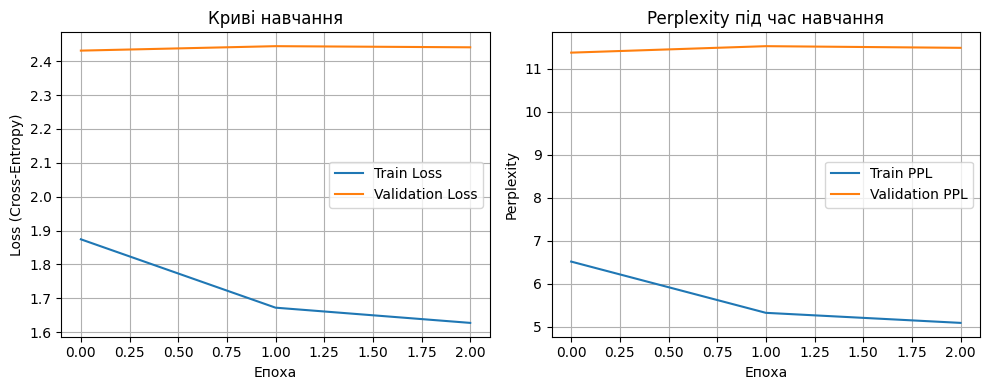

In [23]:
# Візуалізація навчання
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Епоха')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Криві навчання')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot([np.exp(l) for l in history['train_loss']], label='Train PPL')
plt.plot([np.exp(l) for l in history['val_loss']], label='Validation PPL')
plt.xlabel('Епоха')
plt.ylabel('Perplexity')
plt.title('Perplexity під час навчання')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

#### Результати навчання

| Епоха | Train Loss | Train PPL | Val Loss   | Val PPL   |
| ----- | ---------- | --------- | ---------- | --------- |
| 1     | 1.8743     | 6.52      | **2.4313** | **11.37** |
| 2     | 1.6725     | 5.33      | 2.4444     | 11.52     |
| 3     | —          | —         | —          | —         |

Навчання зупиняв на 3-й епосі через Early Stopping, оскільки валідаційний loss в кінці кінців перестав покращуватися і почав зростати. Загалом LSTM навчалася протягом ~4.5 годин.

**Аналіз отриманого:**

- Найкраща модель отримана вже на **епосі 1** (Val Loss = 2.4313). Це так, бо датасет малий
- Подальше навчання призводило до перенавчання (overfitting): train loss падав, але val loss зростав
- Perplexity ~11 означає, що модель "вибирає" з приблизно 11 рівноймовірних символів. Це прийнятний результат для character-level моделі

В принципі, для навчальних цілей результати є задовільними — модель навчилася генерувати текст, схожий на українську прозу. Нижче в цьому переконаємося

### 6. Генерація тексту

In [24]:
def generate_text(model, vocab, seed_text, length=500, temperature=1.0):
    """
    Генерація тексту на основі початкової фрази.

    Параметри:
    - seed_text: початковий текст для продовження
    - length: кількість символів для генерації
    - temperature: контроль випадковості генерації
        - T = 0.5: консервативний, повторюваний текст
        - T = 0.7-0.8: оптимально для читабельного тексту
        - T = 1.0: стандартний розподіл ймовірностей
        - T > 1.2: хаотичний, з помилками та вигаданими словами
    """
    model.eval()

    # Кодуємо початковий текст
    input_seq = torch.tensor([vocab.encode(seed_text)], dtype=torch.long)

    # Ініціалізація прихованого стану
    hidden = model.init_hidden(1)

    # Прогін початкової послідовності через модель
    with torch.no_grad():
        output, hidden = model(input_seq, hidden)

    # Генерація нових символів
    generated = list(seed_text)

    with torch.no_grad():
        for _ in range(length):
            # Беремо останній вихід
            logits = output[0, -1, :] / temperature

            # Softmax для отримання ймовірностей
            probs = torch.softmax(logits, dim=0)

            # Семплінг наступного символу
            next_idx = torch.multinomial(probs, 1).item()
            next_char = vocab.idx_to_char.get(next_idx, '')

            generated.append(next_char)

            # Оновлення входу для наступної ітерації
            input_seq = torch.tensor([[next_idx]], dtype=torch.long)
            output, hidden = model(input_seq, hidden)

    return ''.join(generated)

# Завантажуємо найкращу збережену модель і викоритосуємо її для генерації тексту
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
print("Successfully loaded the best one!")

Successfully loaded the best one!


In [ ]:
# Приклади генерації з різними температурами (різний ступінь контролю випадковості генерації)
seed_texts = [
    "Україна",
    "Лис Микита",
    "Любов",
    "Мавка сказала",
    "Чому ти"
]

temperatures = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5]

for seed in seed_texts:
    print(f"\n{'='*80}")
    print(f"Seed: '{seed}'")
    print('='*80)

    for temp in temperatures:
        print(f"\n--- Temperature = {temp} ---")
        generated = generate_text(
            model, vocab, seed,
            length=200,
            temperature=temp
        )
        print(generated)


Seed: 'Україна'

--- Temperature = 0.4 ---
Україна, на се про нашого поезії по слов янській поезії в XVIII в. було було видання по просвітній суспільності перед відповідної поезії не знаю, що в своїй поезії «Обертаючи 1897 р. в «Слова» (1873).
 С. 15

--- Temperature = 0.5 ---
Україна, способу також позложеного просторою старої спомини, повстала в тім самім виданні справді про се досить забували тим перекладам виставляє все своє повість, до нас старографічного думку — не те, що на

--- Temperature = 0.6 ---
Україна на дослідів до старших молодежі, з залягнув мови, видання один себе і він за без могили і видання в ньому. Я видання про найдівчання поляками про освіту, а в виданні поетичної докладної співанина, ал

--- Temperature = 0.7 ---
Україна наторочний різним руською старості. Шекспір у Головині герої, що про підходить щось висловою та друкованого і з них дуже не подав роздержував по його духовній еміграції, які найвище здібний не певно,

--- Temperature = 0.8 ---
Україна, він «у 

### 7. Аналіз результатів та метрики

In [29]:
def calculate_metrics(model, dataloader, vocab_size):
    """Розрахунок метрик якості моделі"""
    model.eval()

    total_loss = 0
    total_correct = 0
    total_chars = 0

    criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

    with torch.no_grad():
        for x, y in dataloader:

            hidden = model.init_hidden(x.size(0))
            output, _ = model(x, hidden)

            # Loss
            loss = criterion(output.view(-1, output.size(-1)), y.view(-1))
            total_loss += loss.item()

            # Accuracy
            predictions = output.argmax(dim=-1)
            mask = y != 0  # Ігноруємо padding
            total_correct += (predictions[mask] == y[mask]).sum().item()
            total_chars += mask.sum().item()

    avg_loss = total_loss / total_chars
    perplexity = np.exp(avg_loss)
    accuracy = total_correct / total_chars * 100

    return {
        'loss': avg_loss,
        'perplexity': perplexity,
        'accuracy': accuracy,
        'vocab_size': vocab_size
    }

metrics = calculate_metrics(model, val_loader, vocab.vocab_size)

print("Метрики на валідаційному наборі:")
print(f"  Cross-Entropy Loss: {metrics['loss']:.4f}")
print(f"  Perplexity: {metrics['perplexity']:.2f}")
print(f"  Character Accuracy: {metrics['accuracy']:.2f}%")

print("\n" + "="*50)
print("Інтерпретація метрик:")
print("="*50)
print(f"""
Perplexity (PPL) показує 'плутанину' моделі при передбаченні:
- PPL = 1: ідеальне передбачення
- PPL = {metrics['vocab_size']}: випадкове вгадування"
- PPL = {metrics['perplexity']:.2f}: модель 'вибирає' з ~{metrics['perplexity']:.0f} символів

Character Accuracy показує % правильно передбачених символів.
Для character-level моделі 30-50% є хорошим результатом,
оскільки існує багато правильних варіантів продовження.
""")

Метрики на валідаційному наборі:
  Cross-Entropy Loss: 2.4313
  Perplexity: 11.37
  Character Accuracy: 35.94%

Інтерпретація метрик:

Perplexity (PPL) показує 'плутанину' моделі при передбаченні:
- PPL = 1: ідеальне передбачення
- PPL = 149: випадкове вгадування"
- PPL = 11.37: модель 'вибирає' з ~11 символів

Character Accuracy показує % правильно передбачених символів.
Для character-level моделі 30-50% є хорошим результатом,
оскільки існує багато правильних варіантів продовження.



## Вплив температури на генерацію

**Temperature** — параметр, що контролює випадковість при генерації тексту. Він змінює розподіл ймовірностей наступного символу:

- **T < 1**: загострює розподіл → модель частіше обирає найімовірніший символ
- **T = 1**: оригінальний розподіл без змін
- **T > 1**: згладжує розподіл → всі символи стають більш рівноймовірними

| Temperature | Характеристика                                                              | Приклад                                              |
| ----------- | --------------------------------------------------------------------------- | ---------------------------------------------------- |
| 0.4–0.5     | Консервативний, повторюваний текст. Граматично правильний, але одноманітний | "...видання про поезії на видання..."                |
| 0.6–0.7     | **Оптимальний баланс.** Зв'язний текст з різноманіттям                      | "...Шекспір у Головині герої, що про підходить..."   |
| 0.8–0.9     | Більше креативності, з'являються незвичні конструкції                       | "...декого нашого поета. Я загально до блискучих..." |
| 1.0         | Стандартний розподіл. Текст читабельний, але з помилками                    | "...обертати бувежить? А коли щородо рішака..."      |
| 1.5+        | Хаос. Розпад структури слів, безглузді комбінації                           | "...Ревне, ти не будпучити боть? тьому!..."          |

**Рекомендована температура**: 0.5–0.7 для генерації читабельного і змістовного тексту. АЛЕ звісно краще більше епох, більший датасет і краще навчання для запуску в Production))

## Метрики якості

| Метрика            | Значення | Інтерпретація                                  |
| ------------------ | -------- | ---------------------------------------------- |
| Cross-Entropy Loss | 2.4313   | Середня "несподіваність" правильного символу   |
| Perplexity (PPL)   | 11.37    | Модель "вибирає" з ~11 рівноймовірних символів |
| Character Accuracy | 35.94%   | Частка правильно передбачених символів         |

**Інтерпретація Perplexity:**

- PPL = 1 — ідеальне передбачення
- PPL = 149 — випадкове вгадування (розмір словника)
- PPL = 11.37 — модель значно краща за випадкову

**Character Accuracy 35.94%** є хорошим результатом для character-level моделі, оскільки для багатьох позицій існує кілька правильних варіантів продовження (наприклад, після "коха" може йти "в", "н", "л", "т" тощо).

## Висновки

Я реалізовував модель character-level LSTM для генерації тексту українською. Для очищення та нормалізації тексту використав preprocessing pipeline -- типовий підхід для препроцесингу при машиному навчанні. А temperature-based sampling -- для контролю "креативності" генерації (існування реальних слів). Переваги обраного мною підходу:
- LSTM добре підходить для датасетів малого/середнього розміру (як раз мій випадок)
- Character-level підхід дозволяє генерувати нові слова
- Модель навчається морфологічним патернам української мови

Щоб досягнути покращень можна використати такі підходи:
1. Використати bidirectional LSTM (моделька яка обробляє послідовні дані в обох напрямках. Це дозволяє їй фіксувати багатший контекст та залежності застосування слів з усієї послідовності, а не лише попередню інформацію)
2. Ще можна поекспериментувати з word-level або subword токенізацією (BPE)
3. Збільшити датасет (додати більше текстів) -- але тоді краще було б і змінити архітектурну модель і використовувати вже трансформерів (на початку описував їх переваги)
4. Провести донавчання (fine-tuning) попередньо навченої моделі на обраному датасеті з виокористанням мовних вже існуючих мовних моделей. До прикладу -- mGPT (Multilingual GPT) або Ukrainian GPT-2 (донавчений українською GPT-2) -- Але це вже теж трансформери

In [ ]:
# Оцю штуку написав аби було, бо на нашому малому датасеті і тій мізерній
# кількості епох, які дозволило зробити відключення, толку з цього буде мало

# Збереження моделі та словника для подальшого використання
import pickle

# Збереження словника
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# Збереження конфігурації моделі
model_config = {
    'vocab_size': vocab.vocab_size,
    'embedding_dim': EMBEDDING_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print("Модель та конфігурацію збережено!")
print("\nФайли:")
print("  - best_model.pth: ваги моделі")
print("  - vocab.pkl: словник символів")
print("  - model_config.pkl: конфігурація моделі")
print("  - training_curves.png: графіки навчання")

Модель та конфігурацію збережено!

Файли:
  - best_model.pth: ваги моделі
  - vocab.pkl: словник символів
  - model_config.pkl: конфігурація моделі
  - training_curves.png: графіки навчання
